In [ ]:
!pip install moabb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.7/228.7 kB 26.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 45.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.0/365.0 kB 48.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 9.9 MB/s eta 0:00:00
  Created wheel for pyriemann: filename=pyriemann-0.3-py2.py3-none-any.whl size=78031 sha256=a26e9c3022c1ed47013777d1c46fbfd4c2cf694952b333cfd65d9267f2da6186
  Stored in directory: /root/.cache/pip/wheels/eb/52/63/ad042f5ca1209b213a326a843e75d730b30bc7a89a79edb187
Successfully built pyriemann
  Attempting uninstall: requests
    Found existing installation: requests 2.27.1
    Uninstalling requests-2.27.1:
      Successfully uninstalled requests-2.27.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are inst

In [ ]:
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import pandas as pd
from copy import copy

import matplotlib.colors as mcolors

from sklearn.decomposition import PCA as sklearnPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

import moabb.analysis.plotting as moabb_plt
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
    collapse_session_scores
)
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.cluster import KMeans

Tensorflow not install, you could not use those pipelines
To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [ ]:
EA_indiv = "indiv_8_seed14-BNCI2014001-alignment-exp_4-0-both_results.csv"
No_EA_indiv = "indiv_8_seed14-BNCI2014001-no-alignment-exp_4-0-both_results.csv"
resultsEA_indiv = pd.read_csv(EA_indiv)
resultsNEA_indiv = pd.read_csv(No_EA_indiv)


In [ ]:
results = pd.concat([resultsEA_indiv,resultsNEA_indiv])

In [ ]:
results

,Unnamed: 0,time,dataset,subject,test,session,score,type,ft,n_samples,n_channels,pipeline,exp
0,0,190.064554,001-2014,1,1,both,0.996528,Offline,Without,288,22,aligned,indiv
1,1,190.064554,001-2014,1,2,session_E,0.483333,Offline,Without,288,22,aligned,indiv
2,2,190.064554,001-2014,1,2,session_E,0.500000,Online,Without,288,22,aligned,indiv_1run
3,3,190.064554,001-2014,1,2,session_T,0.475000,Offline,Without,288,22,aligned,indiv
4,4,190.064554,001-2014,1,2,session_T,0.500000,Online,Without,288,22,aligned,indiv_1run
...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,139,11.480149,001-2014,9,6,session_T,0.500000,Online,With,288,22,non-aligned,indiv_ft
437,140,8.463223,001-2014,9,7,session_E,0.491667,Online,With,288,22,non-aligned,indiv_ft
438,141,7.481719,001-2014,9,7,session_T,0.500000,Online,With,288,22,non-aligned,indiv_ft
439,142,8.828284,001-2014,9,8,session_E,0.783333,Online,With,288,22,non-aligned,indiv_ft


In [ ]:
results.loc[results['pipeline'] == 'EEGNetv4_EA', 'pipeline'] ='aligned'
results.loc[results['pipeline'] == 'EEGNetv4_Without_EA', 'pipeline'] ='non-aligned'

In [ ]:
def boxplot_model_avg(results):

    sns.set_context('paper')

    sns.set_style("ticks")


    figbox, axbox = plt.subplots(figsize=(15,5))

    plt.title(f"Average model accuracy")

    axbox = sns.boxplot(data=results, y="score", x="subject",
                        hue="pipeline", ax=axbox, palette='Greens')
    axbox = sns.stripplot(data=results, y="score", x="subject",
                        hue="pipeline", ax=axbox, dodge=True,
                        linewidth=1, alpha=.5, palette='Greens')

    #sns.move_legend(axbar, "upper left", bbox_to_anchor=(1, 1))
    axbox.set_ylabel("Accuracy")
    axbox.set_xlabel("Models")

    figbox.savefig(f"box_model_avg1000.pdf", format='pdf', dpi=300, bbox_inches='tight')

    plt.show()

In [ ]:
def boxplot_subj_avg(results):

    cmap = sns.color_palette("BuGn", as_cmap=True)

    sns.set_context('paper')

    sns.set_style("ticks")


    figbox, axbox = plt.subplots(figsize=(15,5))

    plt.title(f"Average test subject accuracy")

    axbox = sns.boxplot(data=results, y="score", x="test",
                        hue="pipeline", ax=axbox, palette='Greens')
    axbox = sns.stripplot(data=results, y="score", x="test",
                        hue="pipeline", ax=axbox, dodge=True,
                        linewidth=1, alpha=.5,  palette='Greens')


    #sns.move_legend(axbar, "upper left", bbox_to_anchor=(1, 1))
    axbox.set_ylabel("Accuracy")
    axbox.set_xlabel("Subjects")

    figbox.savefig(f"box_test_avg1000.pdf", format='pdf', dpi=300, bbox_inches='tight')

    plt.show()

In [ ]:
results_indiv = copy(results[results['exp']=='indiv'])

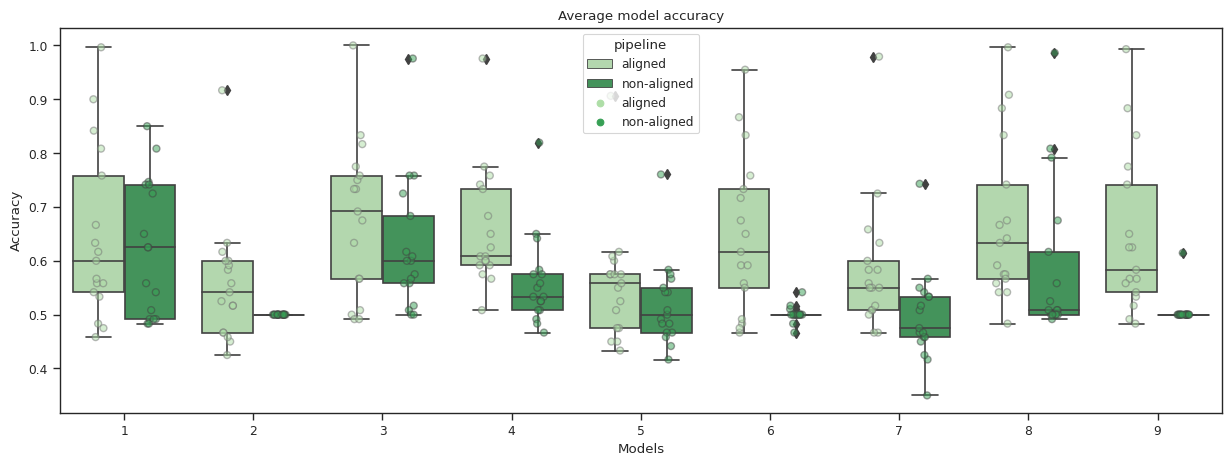

In [ ]:
boxplot_model_avg(results_indiv)

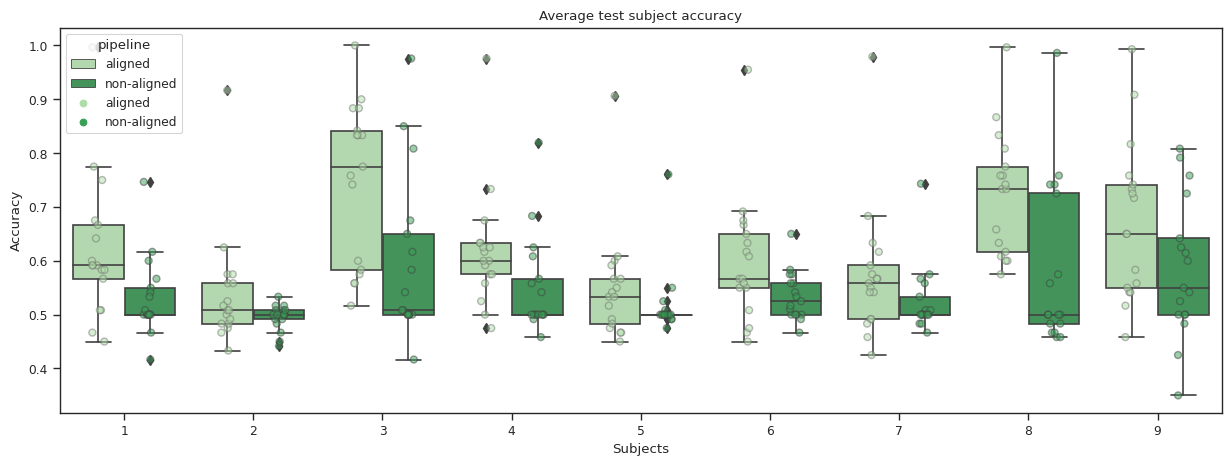

In [ ]:
boxplot_subj_avg(results_indiv)

In [ ]:
# Prepare data for the next plot
results_indiv_donor = copy(results_indiv)
results_indiv_donor['type'] = 'donor'
results_indiv_donor.drop(columns=["test"], inplace=True)

results_indiv_receiver = copy(results_indiv)
results_indiv_receiver['type'] = 'receiver'
results_indiv_receiver.drop(columns=["subject"], inplace=True)
results_indiv_receiver.rename(columns={"test": "subject"}, inplace=True)

results_stripplot = pd.concat([results_indiv_donor,results_indiv_receiver])

In [ ]:
results_stripplot

,Unnamed: 0,time,dataset,subject,session,score,type,ft,n_samples,n_channels,pipeline,exp
0,0,190.064554,001-2014,1,both,0.996528,donor,Without,288,22,aligned,indiv
1,1,190.064554,001-2014,1,session_E,0.483333,donor,Without,288,22,aligned,indiv
3,3,190.064554,001-2014,1,session_T,0.475000,donor,Without,288,22,aligned,indiv
5,5,190.064554,001-2014,1,session_E,0.841667,donor,Without,288,22,aligned,indiv
7,7,190.064554,001-2014,1,session_T,0.900000,donor,Without,288,22,aligned,indiv
...,...,...,...,...,...,...,...,...,...,...,...,...
287,287,43.324965,001-2014,6,session_T,0.500000,receiver,Without,288,22,non-aligned,indiv
289,289,43.324965,001-2014,7,session_E,0.500000,receiver,Without,288,22,non-aligned,indiv
291,291,43.324965,001-2014,7,session_T,0.500000,receiver,Without,288,22,non-aligned,indiv
293,293,43.324965,001-2014,8,session_E,0.500000,receiver,Without,288,22,non-aligned,indiv


In [ ]:
def boxplot_dots(results):

    colors = sns.color_palette("BuGn")
    cmap = sns.color_palette("BuGn", as_cmap=True)
    sns.set_context('paper')

    sns.set_style("ticks")


    figbox, axbox = plt.subplots(figsize=(15,5))

    axbox = sns.boxplot(data= results, y="score", x="subject", hue='type',
                        ax=axbox, palette='Greens')
    axbox = sns.stripplot(data=results, y="score", x="subject",
                        hue="type", ax=axbox, dodge=True,
                        linewidth=1, alpha=.5,  palette='Greens')
    #sns.move_legend(axbar, "upper left", bbox_to_anchor=(1, 1))
    axbox.set_ylabel("Accuracy")
    axbox.set_xlabel("Subjects")

    figbox.savefig(f"box_dots.pdf", format='pdf', dpi=300, bbox_inches='tight')

    plt.show()

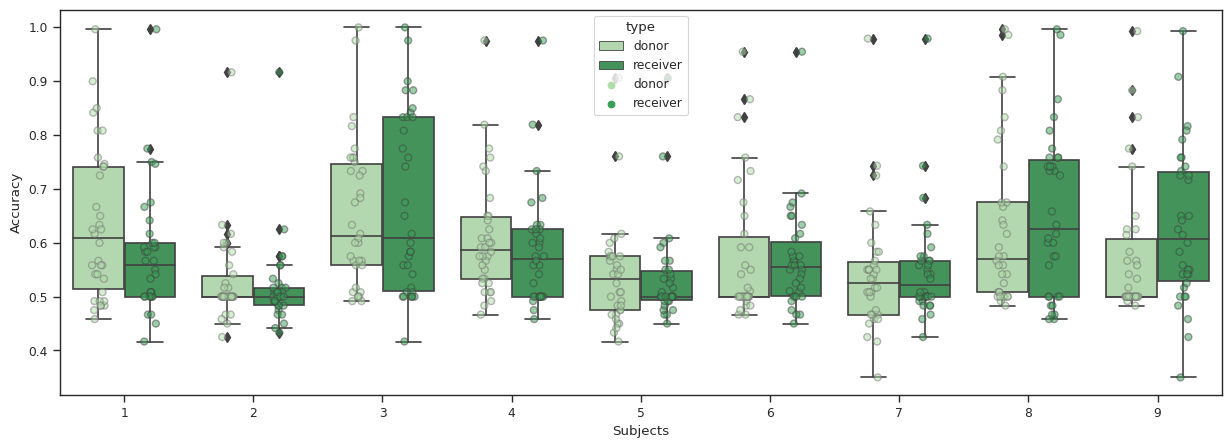

In [ ]:
boxplot_dots(results_stripplot)

In [ ]:
# Collapse JUST sessions
def collapse_session_scores_(df):
    """Prepare results dataframe for computing statistics

    Parameters
    ----------
    df: DataFrame
        results from evaluation

    Returns
    -------
    df: DataFrame
        Aggregated results, samples are index, columns are pipelines,
        and values are scores
    """
    return (
        df.groupby(["pipeline", "dataset", "subject","test"])
        .mean(numeric_only=True)
        .reset_index()
    )


In [ ]:
results_indiv_hp = collapse_session_scores_(results_indiv)

In [ ]:
results_indiv_hp

,pipeline,dataset,subject,test,Unnamed: 0,time,score,n_samples,n_channels
0,aligned,001-2014,1,1,0.0,190.064554,0.996528,288.0,22.0
1,aligned,001-2014,1,2,2.0,190.064554,0.479167,288.0,22.0
2,aligned,001-2014,1,3,6.0,190.064554,0.870833,288.0,22.0
3,aligned,001-2014,1,4,10.0,190.064554,0.595833,288.0,22.0
4,aligned,001-2014,1,5,14.0,190.064554,0.566667,288.0,22.0
...,...,...,...,...,...,...,...,...,...
157,non-aligned,001-2014,9,5,282.0,43.324965,0.500000,288.0,22.0
158,non-aligned,001-2014,9,6,286.0,43.324965,0.500000,288.0,22.0
159,non-aligned,001-2014,9,7,290.0,43.324965,0.500000,288.0,22.0
160,non-aligned,001-2014,9,8,294.0,43.324965,0.500000,288.0,22.0


In [ ]:
# Prepare dataframe for the plot
results_indiv_hp_EA = results_indiv_hp[results_indiv_hp['pipeline']=='aligned']

results_heatmap_EA = results_indiv_hp_EA.pivot(index='subject', columns='test', values='score')

results_heatmap_EA['average'] = results_heatmap_EA.mean(axis=0)

results_heatmap_EA.loc[len(results_heatmap_EA.index)+1] = results_heatmap_EA.mean(axis=1)
results_heatmap_EA['average'][10] = results_heatmap_EA['average'].mean()
results_heatmap_EA.index  = results_heatmap_EA.index[:-1].tolist()+["average"]

In [ ]:
# Prepare dataframe for the plot
results_indiv_hp_noEA = results_indiv_hp[results_indiv_hp['pipeline']=='non-aligned']

results_heatmap_noEA = results_indiv_hp_noEA.pivot(index='subject', columns='test', values='score')

results_heatmap_noEA['average'] = results_heatmap_noEA.mean(axis=0)

results_heatmap_noEA.loc[len(results_heatmap_noEA.index)+1] = results_heatmap_noEA.mean(axis=1)
results_heatmap_noEA['average'][10] = results_heatmap_noEA['average'].mean()
results_heatmap_noEA.index  = results_heatmap_noEA.index[:-1].tolist()+["average"]

In [ ]:
def heatplot(results, EA):

    cmap = sns.color_palette("BuGn", as_cmap=True)

    sns.set_context('paper')

    sns.set_style("ticks")

    fig, axes = plt.subplots()

    hm = sns.heatmap(data=results,annot=True, annot_kws={"fontsize":9}, fmt=".2f", cmap=cmap, vmin=0.4, vmax=1) #
    plt.xticks(rotation = 0)
    plt.yticks(rotation = 0)

    #g1.set_title(r'\textbf{EEGNet Architecture}', {'fontsize':16})
    if EA=='EA':
      plt.title(f"Transferability - EEGNet with EA")
    else:
      plt.title(f"Transferability - EEGNet without EA")

    #axes.yaxis.set_visible(False)

    axes.set_ylabel('Model')
    #fig.text(0.5, -0.05, 'Target Subject', ha='center', fontsize=14)

    axes.set_xlabel('Test Subject')
    #fig.text(0.5, -0.05, 'Target Subject', ha='center', fontsize=14)

    # Adjust layout
    #plt.subplots_adjust(wspace=0.1)

    plt.show()

    fig.savefig(f'transferability_{EA}_1000.pdf', format='pdf', dpi=300, bbox_inches='tight')

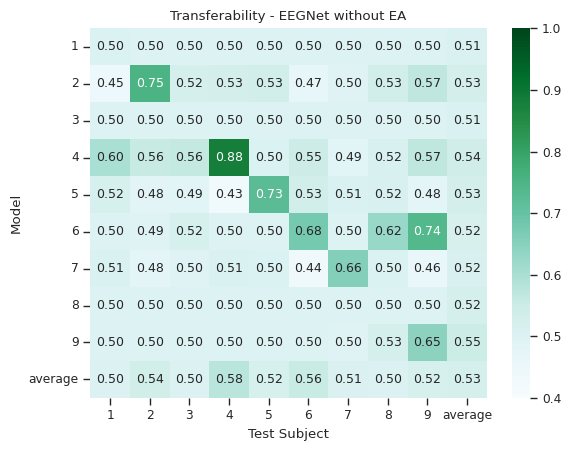

In [ ]:
heatplot(results_heatmap_noEA, "no_EA")

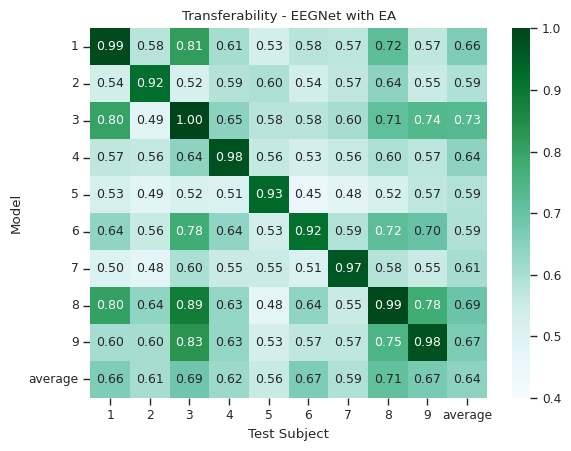

In [ ]:
heatplot(results_heatmap_EA, "EA")